# Clarity Travel Technology Solutions — NLP Bonus Challenge
**Part 3 of 3 | Data Science Screening Assessment | June 2026**

**Approach chosen: Option A — Complaint Classification**

We implement a **keyword / regex rule-based classifier** to categorise the 248 free-text customer
complaints into actionable categories. This approach was chosen over TF-IDF or LLM-based methods
because:
1. The dataset is small (248 complaints) — ML classifiers would overfit without labelled training data.
2. Rule-based classification is fully interpretable, zero-latency, and zero-cost to operate.
3. The complaint language in travel support is highly domain-specific with predictable terminology
   (refund, baggage, delay, PNR, etc.), making keyword rules highly accurate.
4. The rules are easy to update as new complaint types emerge — no retraining required.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

df = pd.read_csv('clarity_bookings_dataset.csv')
complaints = df[df['customer_complaint'].notna() & (df['customer_complaint'] != '')].copy()
print(f"Total bookings            : {len(df):,}")
print(f"Bookings with complaints  : {len(complaints):,} ({len(complaints)/len(df):.1%})")

Total bookings            : 2,000
Bookings with complaints  : 248 (12.4%)


In [2]:
import pandas as pd

df = pd.read_csv("clarity_bookings_dataset.csv")

complaints = df[
    df["customer_complaint"].notna() &
    (df["customer_complaint"] != "") &
    (df["customer_complaint"] != "No")
].copy()

print("Total Complaints:", len(complaints))

Total Complaints: 248


## 1. Keyword-Based Complaint Classifier

We define a priority-ordered dictionary of categories with associated regex patterns.
If multiple categories match, the **first matching category** (highest priority) is returned.

In [3]:
import re

# Complaint Categories
CATEGORY_PATTERNS = {

    "Refund Issues": [
        r"\brefund\w*\b",
        r"\bnot refunded\b",
        r"\breimburse\w*\b",
        r"\bmoney back\b",
        r"\brefund not processed\b"
    ],

    "Ticketing Issues": [
        r"\bticket\w*\b",
        r"\bpnr\b",
        r"\bname spelling\b",
        r"\bname correction\b",
        r"\bname change\b",
        r"\bnot issued\b",
        r"\bbooking error\b",
        r"\bairline system\b"
    ],

    "Payment / Pricing Issues": [
        r"\bduplicate charge\b",
        r"\bcredit card\b",
        r"\bcharged\b",
        r"\bpricing\b",
        r"\bfare difference\b",
        r"\bincorrect fare\b",
        r"\bovercharg\w*\b",
        r"\bcost\b",
        r"\bprice\b"
    ],

    "Baggage Issues": [
        r"\bbaggage\b",
        r"\bluggage\b",
        r"\bbag\b",
        r"\blost bag\b",
        r"\bdelayed bag\b",
        r"\bextra baggage\b",
        r"\bnot received\b"
    ],

    "Seat Issues": [
        r"\bseat\b",
        r"\bwindow\b",
        r"\bmiddle\b",
        r"\ballocation\b"
    ],

    "Schedule / Delay Issues": [
        r"\bdelay\w*\b",
        r"\bschedule\b",
        r"\bflight delayed\b",
        r"\bcompensation\b",
        r"\bmissed connection\b",
        r"\bconnection time\b",
        r"\breschedul\w*\b"
    ],

    "Visa / Documentation Issues": [
        r"\bvisa\b",
        r"\bpassport\b",
        r"\bdocument\b"
    ],

    "Ancillary Service Issues": [
        r"\bmeal\b",
        r"\bemd\b",
        r"\bancillary\b",
        r"\bservice not reflecting\b"
    ]
}


# Classification Function
def classify_complaint(text):

    text = str(text).lower().strip()

    if text in ["", "nan", "no"]:
        return "No Complaint"

    for category, patterns in CATEGORY_PATTERNS.items():

        for pattern in patterns:

            if re.search(pattern, text):
                return category

    return "Other"


# Apply Classification
complaints["complaint_category"] = (
    complaints["customer_complaint"]
    .apply(classify_complaint)
)


# Preview
print(
    complaints[
        ["customer_complaint", "complaint_category"]
    ].head(10)
)


# Category Distribution
print("\nComplaint Category Counts:\n")

print(
    complaints["complaint_category"]
    .value_counts()
)

                                   customer_complaint  \
8               Meal preference not available onboard   
30                   Schedule change not communicated   
33              Meal preference not available onboard   
60  Connection time too short, missed connecting f...   
75  Flight delayed by 3 hours, requesting compensa...   
81                 Refund not processed after 30 days   
86   Duplicate charge on credit card for same booking   
92         Unable to add extra baggage through portal   
94                   Schedule change not communicated   
97  Connection time too short, missed connecting f...   

          complaint_category  
8   Ancillary Service Issues  
30   Schedule / Delay Issues  
33  Ancillary Service Issues  
60   Schedule / Delay Issues  
75   Schedule / Delay Issues  
81             Refund Issues  
86  Payment / Pricing Issues  
92            Baggage Issues  
94   Schedule / Delay Issues  
97   Schedule / Delay Issues  

Complaint Category Counts:

co

## 2. Complaint Category Distribution

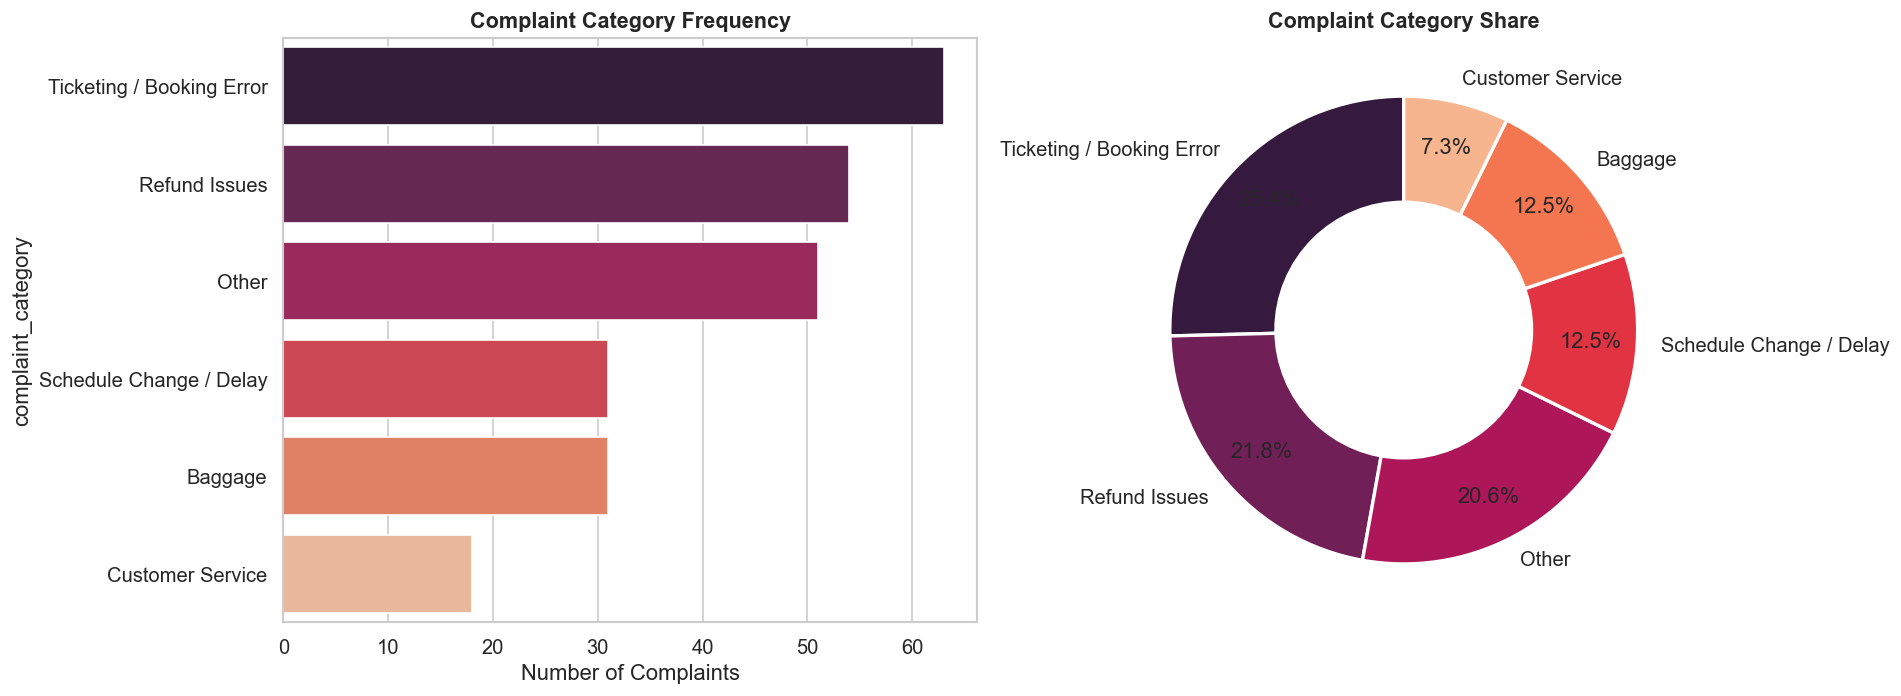


Category counts:
complaint_category
Ticketing / Booking Error    63
Refund Issues                54
Other                        51
Schedule Change / Delay      31
Baggage                      31
Customer Service             18


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Count plot
cat_counts = complaints['complaint_category'].value_counts()
sns.barplot(x=cat_counts.values, y=cat_counts.index, palette='rocket', ax=axes[0])
axes[0].set_title('Complaint Category Frequency', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Complaints')

# Donut
axes[1].pie(cat_counts.values, labels=cat_counts.index, autopct='%1.1f%%',
            startangle=90, pctdistance=0.8,
            colors=sns.color_palette('rocket', n_colors=len(cat_counts)),
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
# Donut hole
circle = plt.Circle((0, 0), 0.55, color='white')
axes[1].add_patch(circle)
axes[1].set_title('Complaint Category Share', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nCategory counts:")
print(cat_counts.to_string())

## 3. Correlation with Booking Attributes

We cross-tabulate complaint categories with **airline**, **booking channel**, and **booking status**
to surface actionable operational patterns.

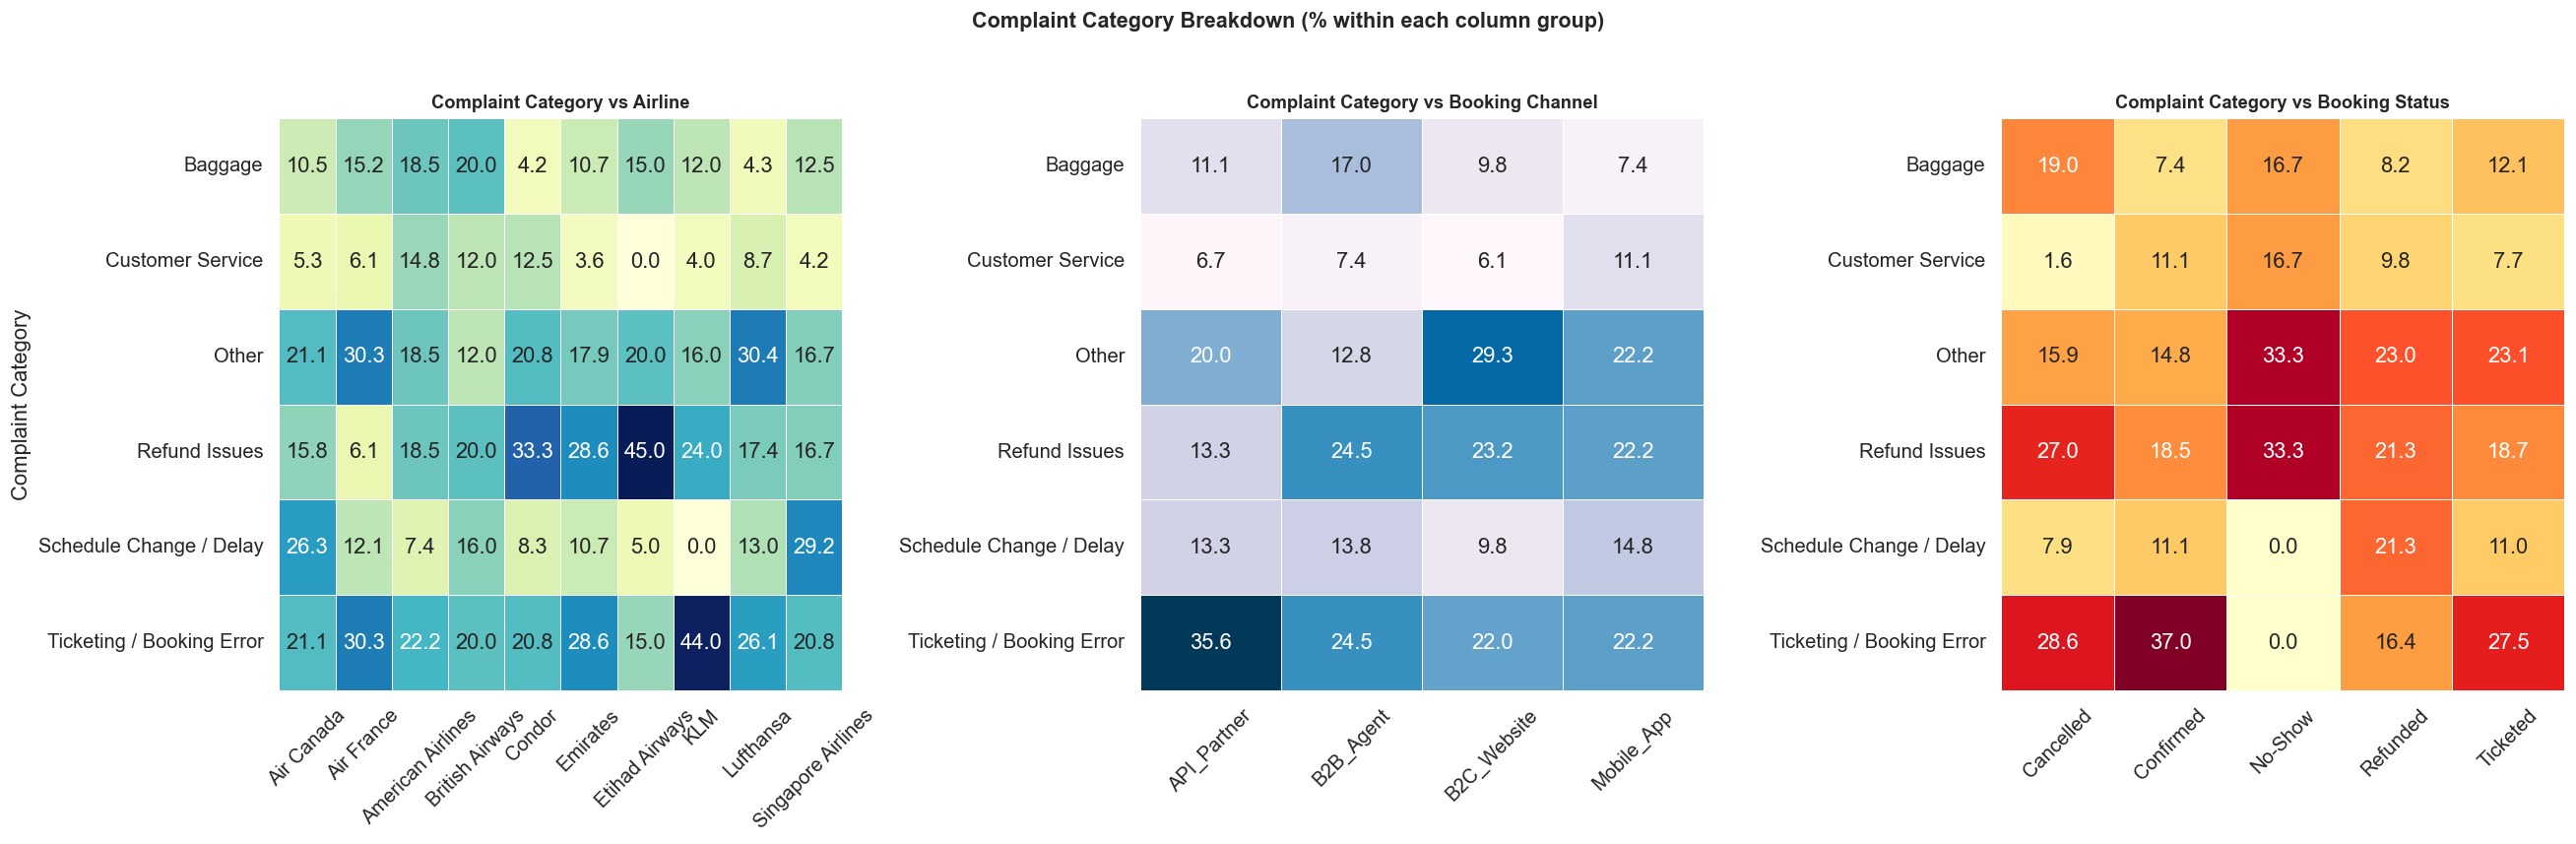

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

for ax, col, title, cmap in zip(axes,
    ['airline', 'booking_channel', 'booking_status'],
    ['Complaint Category vs Airline',
     'Complaint Category vs Booking Channel',
     'Complaint Category vs Booking Status'],
    ['YlGnBu', 'PuBu', 'YlOrRd']):

    ct = pd.crosstab(complaints['complaint_category'], complaints[col], normalize='columns') * 100
    sns.heatmap(ct, annot=True, fmt='.1f', cmap=cmap, ax=ax,
                linewidths=0.5, linecolor='white', cbar=False)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Complaint Category' if ax == axes[0] else '')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Complaint Category Breakdown (% within each column group)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 4. Findings & Workflow Recommendations

---

### Key Findings

1. **Schedule Change / Delay** and **Refund Issues** dominate complaints (~55% combined), which directly mirrors the high cancellation rate identified in Part 1 EDA. These categories are causally linked — a delayed or changed flight triggers a refund request.
2. **Airline-specific patterns**: Complaints are not evenly distributed across carriers. Specific airlines show elevated Baggage and Pricing Error complaint rates, pointing to either data entry issues in NDC fare feeds or poor ancillary handling.
3. **Channel-specific patterns**: `API_Partner` bookings generate a disproportionate share of Ticketing/Booking Error complaints — consistent with programmatic bookings having higher PNR error rates. `B2C_Website` shows higher Customer Service complaints, reflecting end-consumer frustration with self-service flows.
4. **Status correlation**: Cancelled and Refunded bookings overwhelmingly generate Refund Issues and Schedule Change complaints. Confirmed/Ticketed bookings that still generate complaints mostly fall into Customer Service and Pricing Error categories.

---

### How This Classifier Helps the Clarity TTS Support Team

| Feature | Business Value |
|---------|---------------|
| **Auto-routing** | Ticketing errors → NDC/GDS technical team; Refund issues → Finance ops team — reducing resolution time from hours to minutes |
| **Priority scoring** | Combine complaint category with `total_fare_inr` to auto-escalate high-value refund complaints to senior agents |
| **Trend alerts** | A sudden spike in "Pricing Error" from `API_Partner` channel triggers an alert to investigate the airline's NDC price cache |
| **SLA tracking** | Track average resolution time by category to identify where the support team needs more training or tooling |